# Analisi Comparativa delle Performance e Metriche RAG

Questo notebook analizza e confronta le performance di diversi algoritmi di RAG (**Puro**, **Ibrido**, **Rerank**, **Graph**) in due ambienti di esecuzione:
- **Cloud**: basato su API OpenAI (`gpt-4o-mini`)
- **Locale**: basato su esecuzione locale (`phi3.5`)

Le valutazioni sono effettuate sia in lingua inglese (`en`) che italiana (`it`) su chunk di dimensione `700` estratti con il metodo `pdf4llm`.

Le metriche analizzate si dividono in:
1. **Metriche RAGAS**: *Faithfulness* (Fedeltà), *Answer Relevancy* (Pertinenza), *Context Precision* (Precisione del Contesto), *Context Recall* (Richiamo del Contesto).
2. **Accuratezza Risposte**: *Hit Rate (%)* (Percentuale di risposte corrette valutata dal LLM).
3. **Efficienza**: *Tempo medio di risposta (secondi)*.

In [1]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

In [2]:
def parse_quick_eval_reports(directory_path):
    """
    Legge tutti i file markdown nella cartella quick_eval ed estrae le metriche per caricarle in DataFrame.
    """
    ragas_data = []
    llm_data = []
    
    # 1. Parsing dei file RAGAS
    ragas_pattern = os.path.join(directory_path, "ragas_eval_summary_*.md")
    for filepath in glob.glob(ragas_pattern):
        filename = os.path.basename(filepath)
        # Formato: ragas_eval_summary_{env}_{lang}_{chunk}_{rag}_{metodo}_{model}.md
        parts = filename.replace('.md', '').split('_')
        if len(parts) < 8:
            continue
        env = parts[3]
        lang = parts[4]
        chunk = parts[5]
        rag = parts[6]
        
        metrics = {
            'env': env,
            'lang': lang,
            'chunk': int(chunk),
            'rag': rag,
        }
        
        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()
            
        # Trova righe come: | **Faithfulness (Fedeltà)** | 0.7643 |
        matches = re.findall(r'\|\s*\*\*([^*]+)\*\*\s*\|\s*([\d\.\-]+)\s*\|', content)
        for name, val in matches:
            name_clean = name.strip()
            try:
                val_float = float(val)
            except ValueError:
                continue
            if 'Faithfulness' in name_clean:
                metrics['Faithfulness'] = val_float
            elif 'Answer Relevancy' in name_clean:
                metrics['Answer Relevancy'] = val_float
            elif 'Context Precision' in name_clean:
                metrics['Context Precision'] = val_float
            elif 'Context Recall' in name_clean:
                metrics['Context Recall'] = val_float
                
        ragas_data.append(metrics)
        
    # 2. Parsing dei file Risultati LLM
    llm_pattern = os.path.join(directory_path, "llm_results_summary_*.md")
    for filepath in glob.glob(llm_pattern):
        filename = os.path.basename(filepath)
        parts = filename.replace('.md', '').split('_')
        if len(parts) < 8:
            continue
        env = parts[3]
        lang = parts[4]
        chunk = parts[5]
        rag = parts[6]
        
        metrics = {
            'env': env,
            'lang': lang,
            'chunk': int(chunk),
            'rag': rag,
        }
        
        with open(filepath, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            
        for line in lines:
            if '|' not in line or ':---' in line or 'Metric' in line:
                continue
            row_parts = [p.strip() for p in line.split('|')[1:-1]]
            if len(row_parts) < 2:
                continue
            metric_name = row_parts[0].replace('**', '').strip()
            val_str = row_parts[1]
            
            if 'Hit Rate' in metric_name:
                metrics['Hit Rate (%)'] = float(val_str.replace('%', '').strip())
            elif 'Tempo medio risposta' in metric_name:
                metrics['Response Time (s)'] = float(val_str.replace('s', '').strip())
            elif 'Domande valutate' in metric_name:
                metrics['Total Questions'] = int(val_str)
                
        llm_data.append(metrics)
        
    return pd.DataFrame(ragas_data), pd.DataFrame(llm_data)

In [3]:
quick_eval_dir = "../tests/results_llm/quick_eval"
df_ragas, df_llm = parse_quick_eval_reports(quick_eval_dir)

rag_order = ['puro', 'ibrido', 'rerank', 'graph']
df_ragas['rag'] = pd.Categorical(df_ragas['rag'], categories=rag_order, ordered=True)
df_llm['rag'] = pd.Categorical(df_llm['rag'], categories=rag_order, ordered=True)

df_ragas = df_ragas.sort_values('rag')
df_llm = df_llm.sort_values('rag')

print(f"RAGAS Data loaded: {len(df_ragas)} rows")
print(f"LLM Data loaded: {len(df_llm)} rows")

RAGAS Data loaded: 16 rows
LLM Data loaded: 16 rows


In [4]:
FIGSIZE = (20, 20)
TITLE_FONTSIZE = 25
LABEL_FONTSIZE = 20
LEGEND_FONTSIZE = 18
LEGEND_TITLE_FONTSIZE = 20
BAR_FONTSIZE = 18

## 1. Confronto delle Metriche RAGAS in Cloud

In questa sezione confrontiamo le metriche RAGAS (*Faithfulness*, *Answer Relevancy*, *Context Precision*, *Context Recall*) per i 4 tipi di RAG (**Puro**, **Ibrido**, **Rerank**, **Graph**) eseguiti in **Cloud** (con modello `gpt-4o-mini`).

Mostriamo un pool di colonne per ciascuna metrica/feature per valutare a colpo d'occhio quale algoritmo performa meglio.

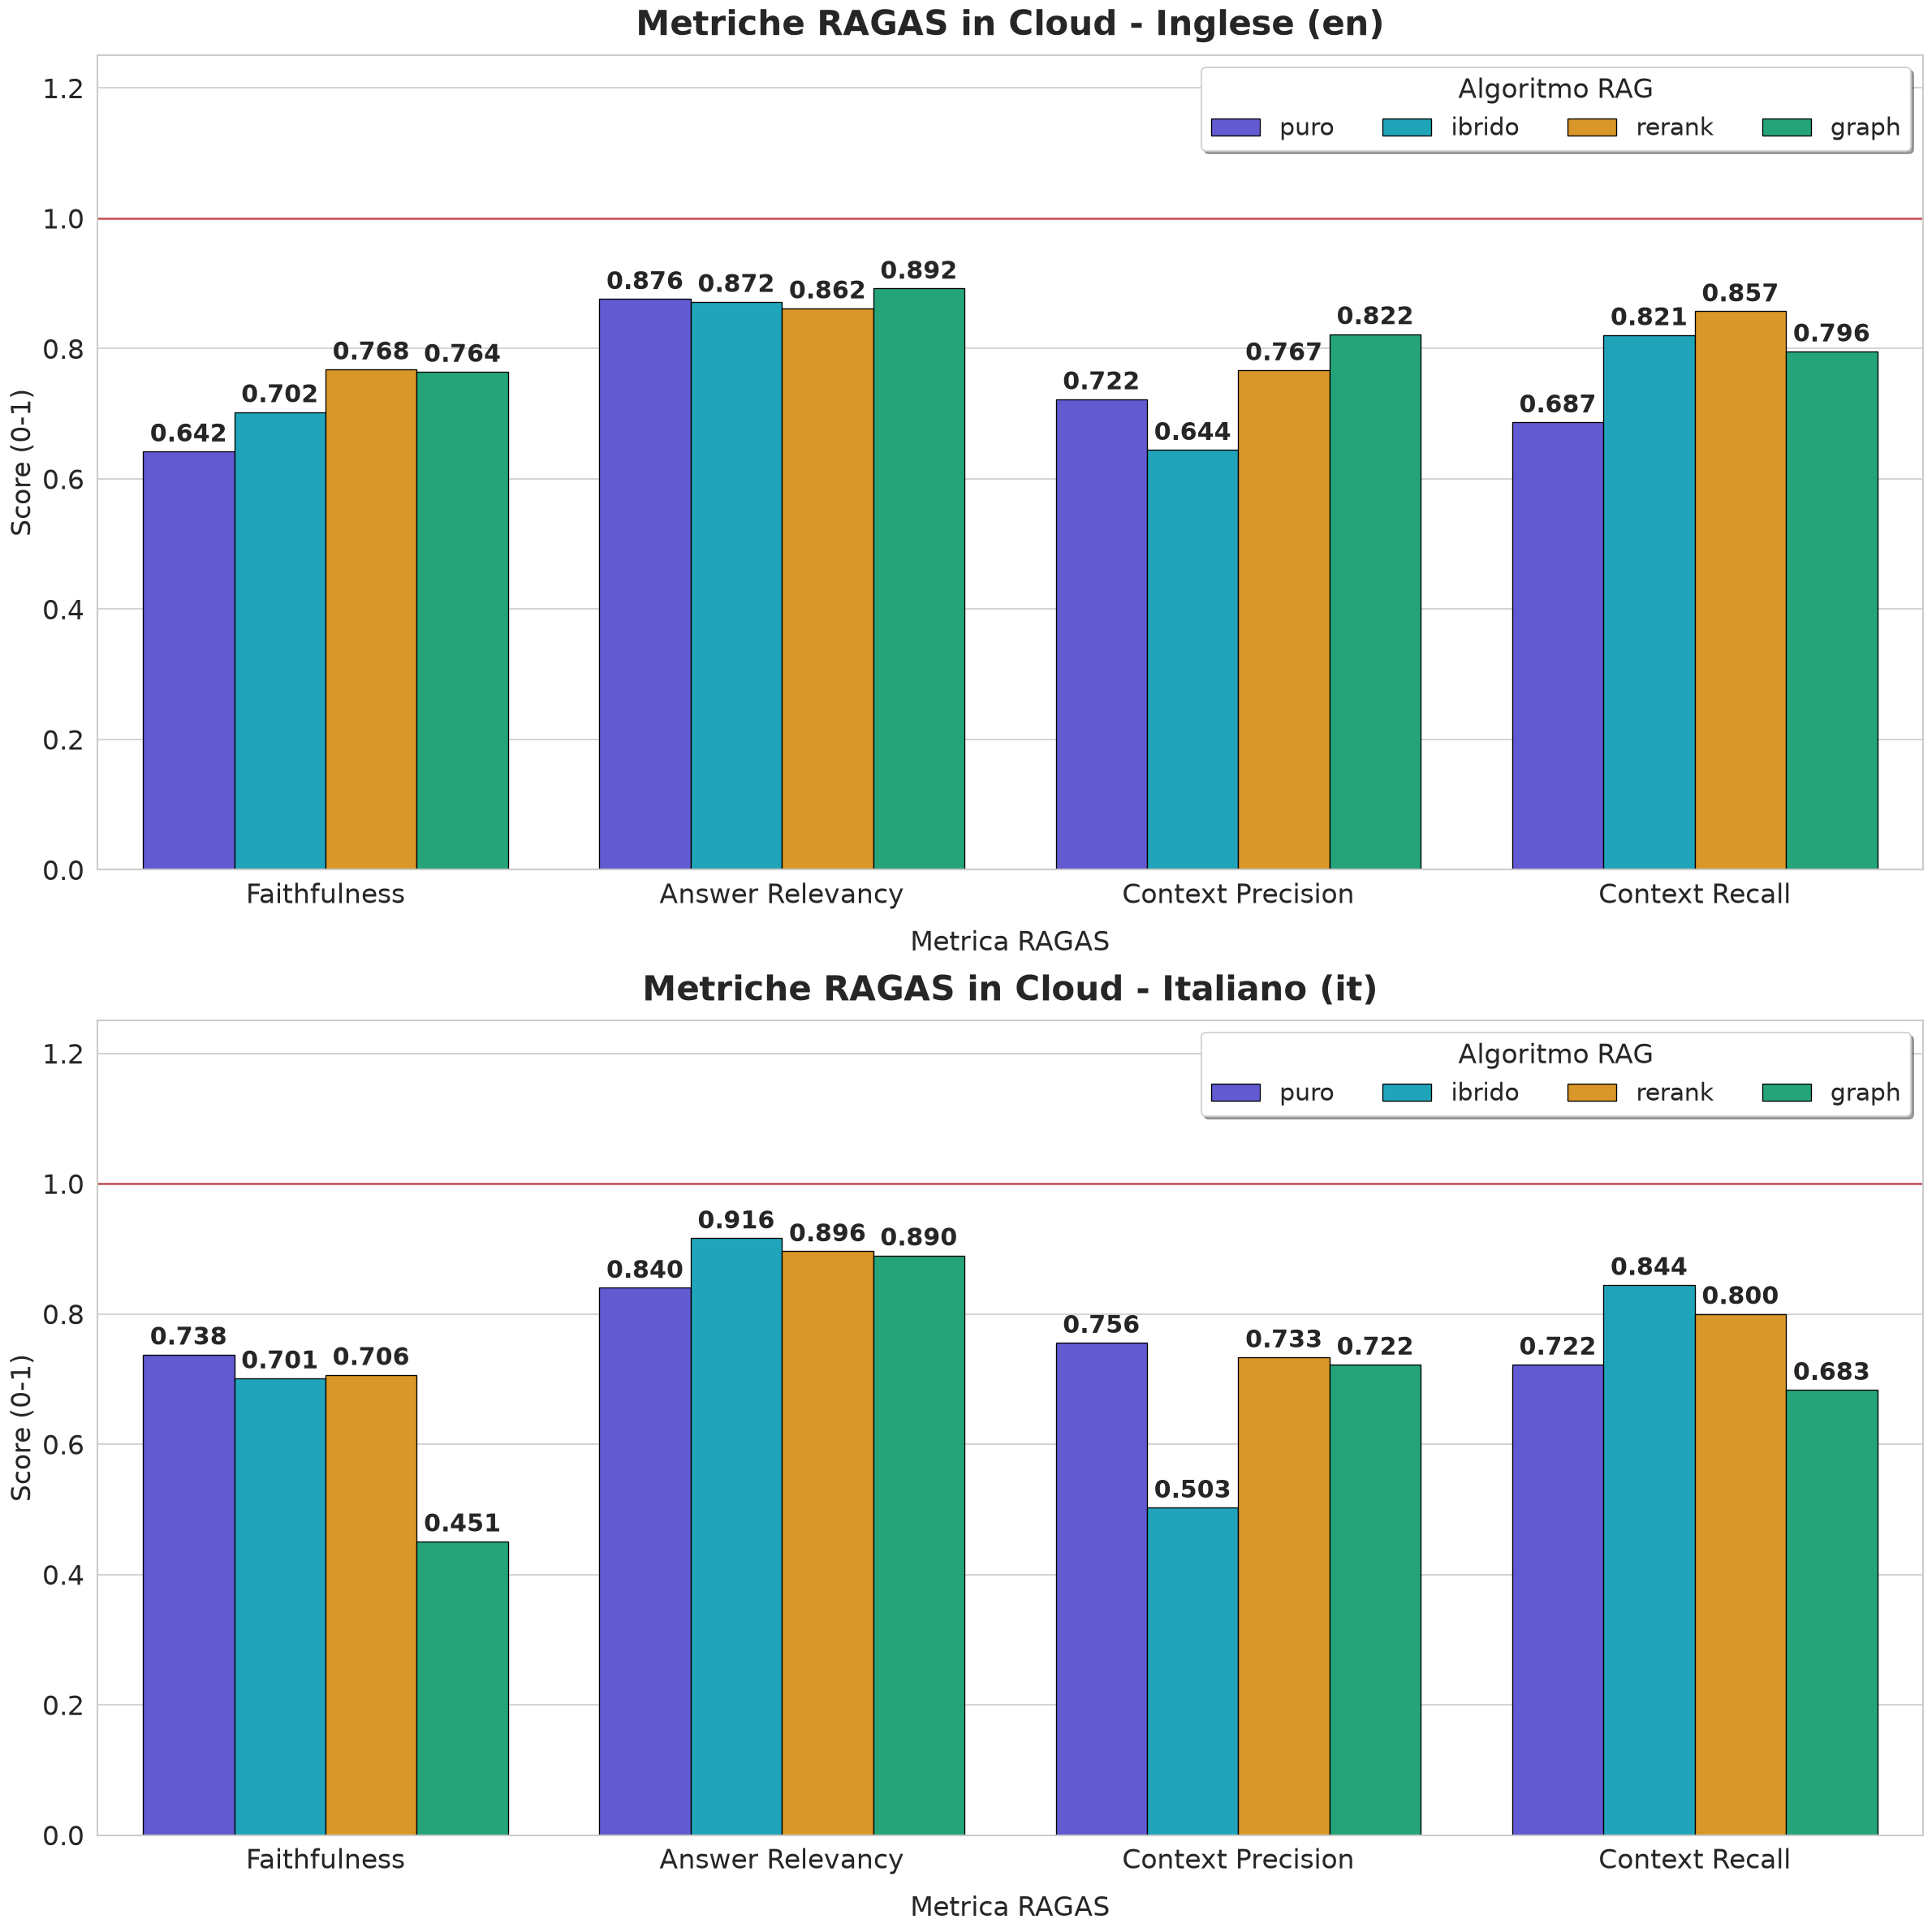

In [11]:
df_ragas_long = df_ragas.melt(
    id_vars=['env', 'lang', 'chunk', 'rag'],
    value_vars=['Faithfulness', 'Answer Relevancy', 'Context Precision', 'Context Recall'],
    var_name='Metric',
    value_name='Score'
)

df_cloud_ragas = df_ragas_long[df_ragas_long['env'] == 'cloud']

colors_rag = {
    'puro': '#4f46e5',    # Indigo
    'ibrido': '#06b6d4',  # Cyan
    'rerank': '#f59e0b',  # Amber
    'graph': '#10b981'    # Emerald
}
rag_order = ['puro', 'ibrido', 'rerank', 'graph']

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE, sharey=True)
langs = ['en', 'it']
titles = ['Metriche RAGAS in Cloud - Inglese (en)', 'Metriche RAGAS in Cloud - Italiano (it)']

for ax, lang, title in zip(axes, langs, titles):
    data_subset = df_cloud_ragas[df_cloud_ragas['lang'] == lang]
    
    sns.barplot(
        data=data_subset,
        x='Metric',
        y='Score',
        hue='rag',
        hue_order=rag_order,
        ax=ax,
        palette=colors_rag,
        edgecolor='black',
        linewidth=0.8
    )
    
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight='bold', pad=15)
    ax.set_ylim(0, 1.25)
    ax.set_xlabel('Metrica RAGAS', fontsize=LABEL_FONTSIZE, labelpad=15)
    ax.set_ylabel('Score (0-1)', fontsize=LABEL_FONTSIZE)
    
    ax.axhline(y=1, color='r')

    ax.legend(
        title='Algoritmo RAG',
        frameon=True,
        loc='upper right',
        ncol=4,
        shadow=True,
        fontsize=LEGEND_FONTSIZE,
        title_fontsize=LEGEND_TITLE_FONTSIZE
    )
    
    ax.tick_params(axis='x', labelsize=LABEL_FONTSIZE)
    ax.tick_params(axis='y', labelsize=LABEL_FONTSIZE)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=BAR_FONTSIZE, fontweight='bold')

plt.tight_layout()
plt.savefig("../thesis_report/images/pdf/ragas_strategie.pdf", bbox_inches='tight')
plt.savefig("../thesis_report/images/png/ragas_strategie.png", bbox_inches='tight')
plt.show()

## 2. Confronto dell'Accuratezza LLM (Hit Rate %)

Di seguito confrontiamo l'accuratezza dell'output generato (**Hit Rate %**) tra i 4 tipi di RAG, evidenziando il divario tra l'ambiente **Cloud** (`gpt-4o-mini`) e l'ambiente **Locale** (`phi3.5`).

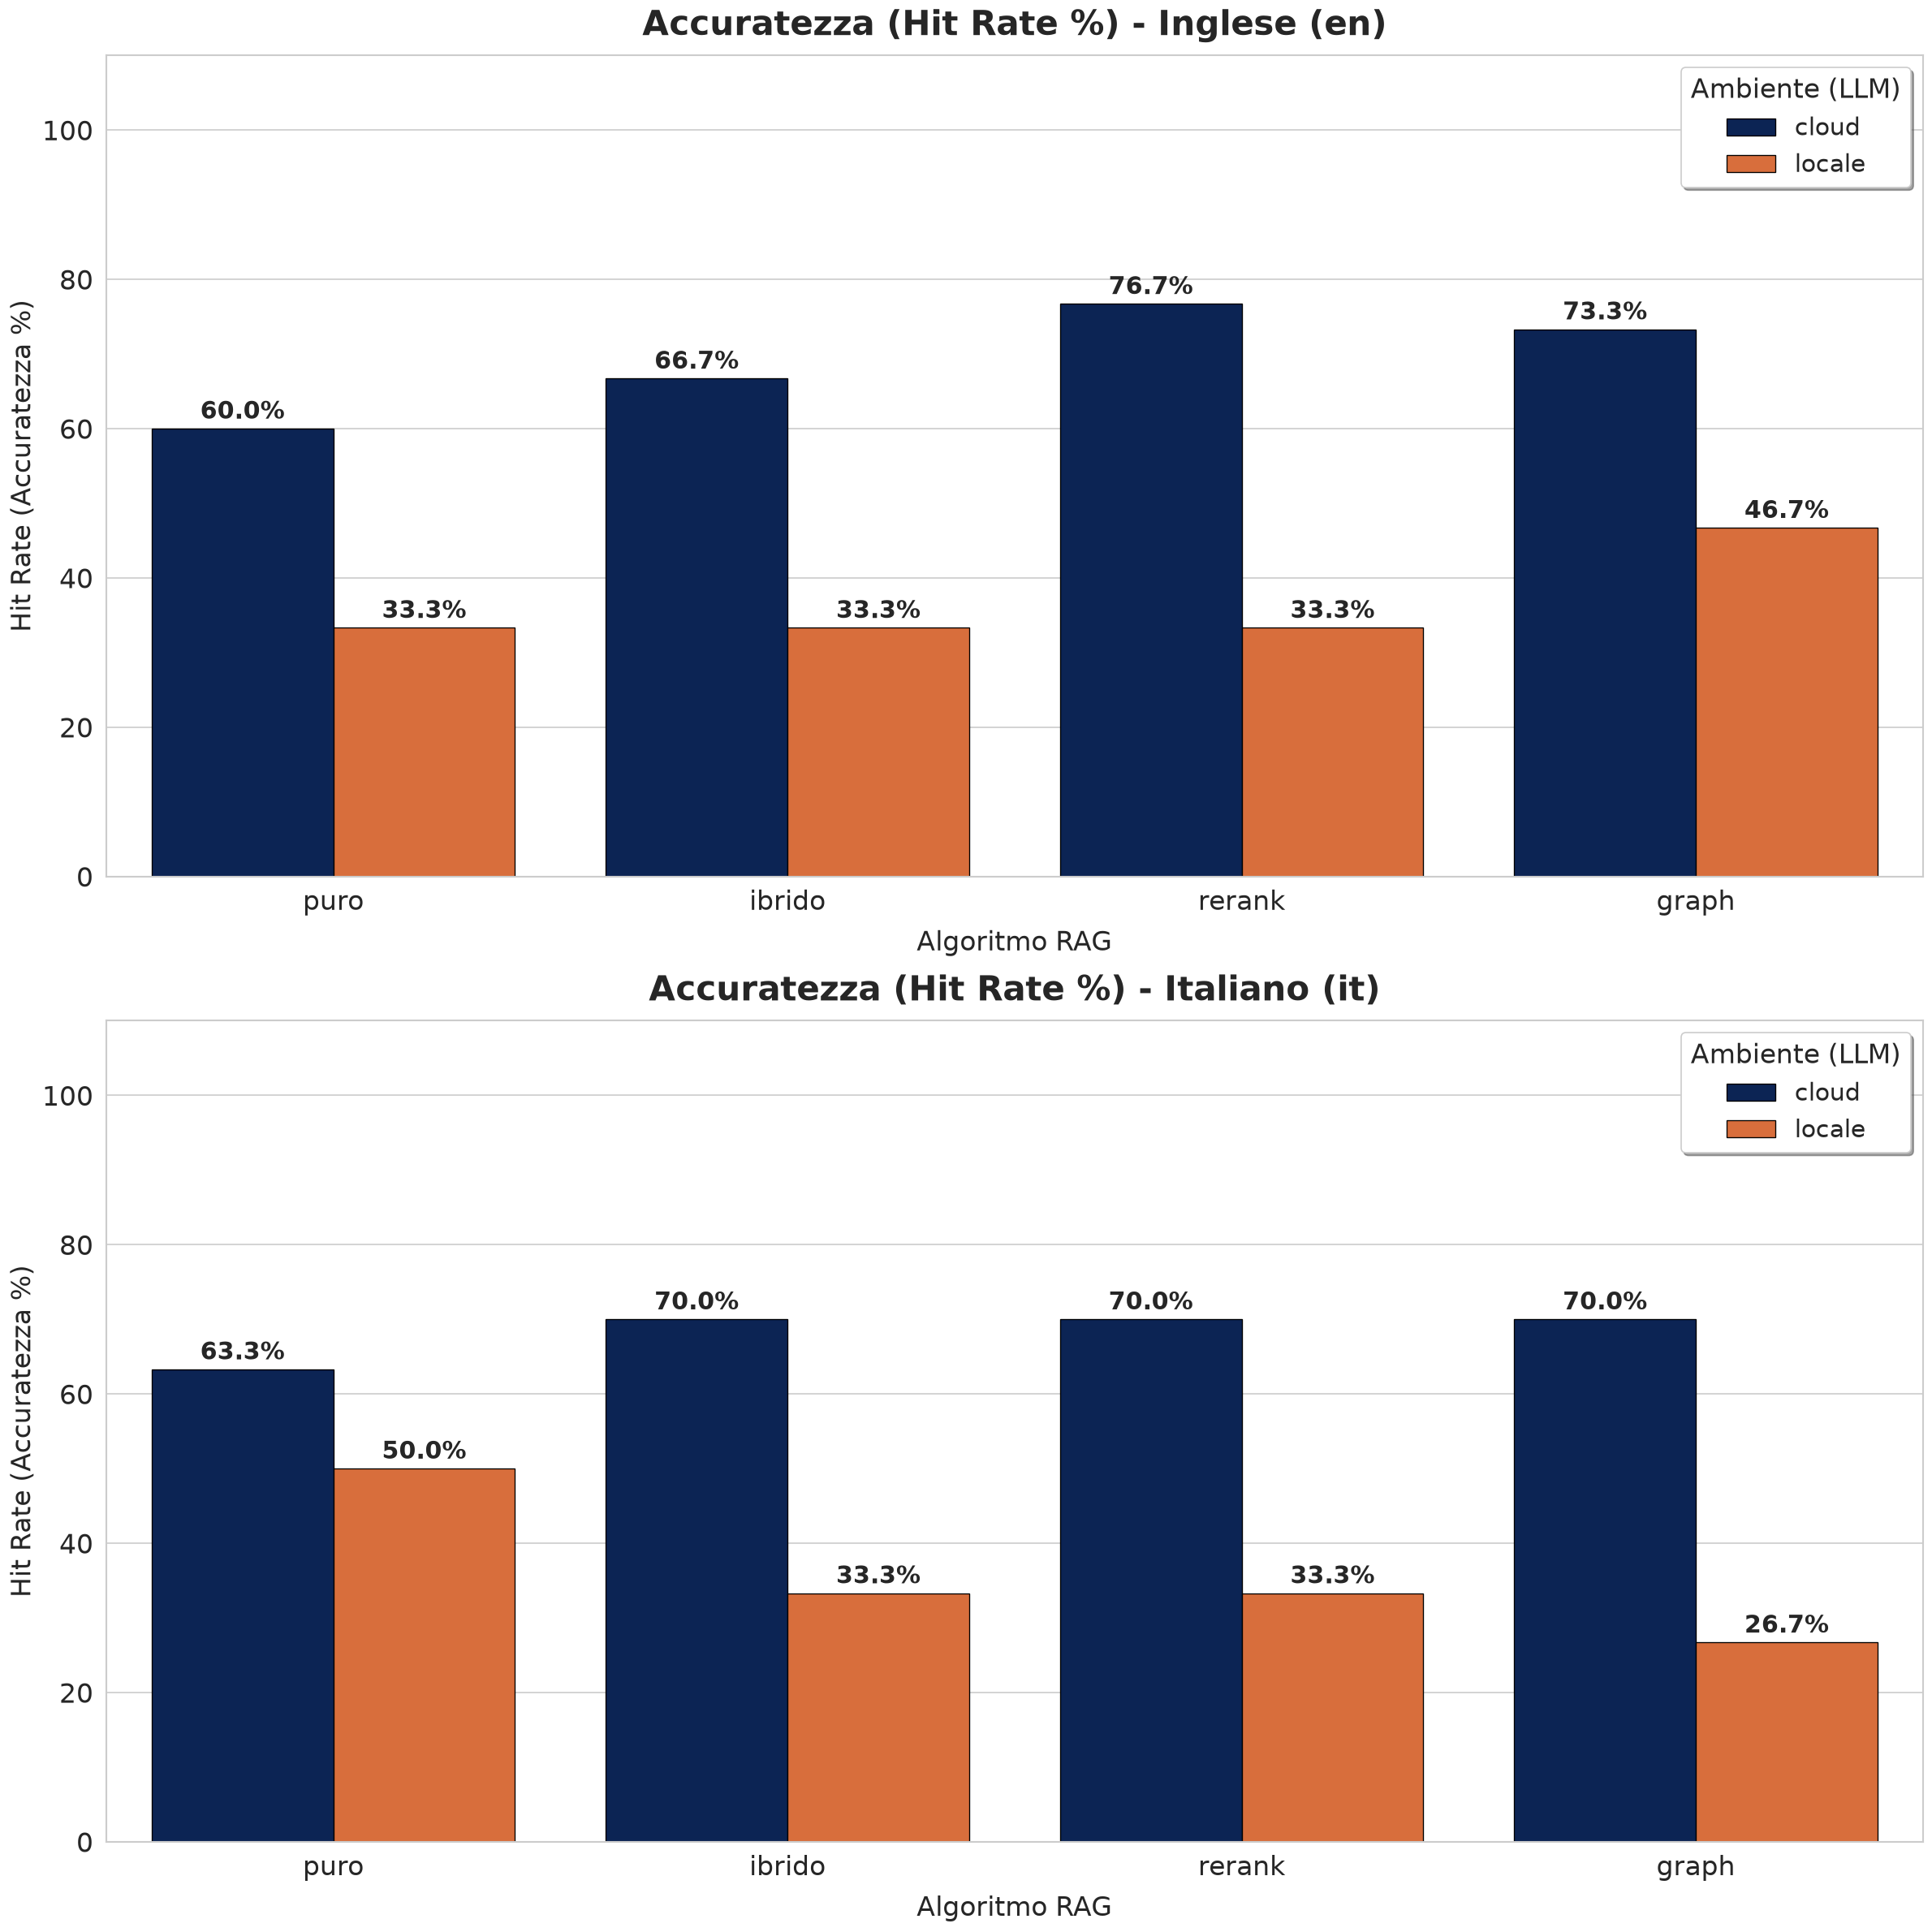

In [10]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE, sharey=True)
langs = ['en', 'it']
titles = ['Accuratezza (Hit Rate %) - Inglese (en)', 'Accuratezza (Hit Rate %) - Italiano (it)']

colors_env = {
    'cloud': '#002060',
    'locale': '#f26522'
}
rag_order = ['puro', 'ibrido', 'rerank', 'graph']

for ax, lang, title in zip(axes, langs, titles):
    data_subset = df_llm[df_llm['lang'] == lang]
    
    sns.barplot(
        data=data_subset,
        x='rag',
        order=rag_order,
        y='Hit Rate (%)',
        hue='env',
        ax=ax,
        palette=colors_env,
        edgecolor='black',
        linewidth=0.8
    )
    
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight='bold', pad=15)
    ax.set_ylim(0, 110)
    ax.set_xlabel('Algoritmo RAG', fontsize=LABEL_FONTSIZE, labelpad=10)
    ax.set_ylabel('Hit Rate (Accuratezza %)', fontsize=LABEL_FONTSIZE)
    
    # Legenda ingrandita
    ax.legend(
        title='Ambiente (LLM)',
        frameon=True,
        shadow=True,
        fontsize=LEGEND_FONTSIZE,
        title_fontsize=LEGEND_TITLE_FONTSIZE
    )

    ax.tick_params(axis='x', labelsize=LABEL_FONTSIZE)
    ax.tick_params(axis='y', labelsize=LABEL_FONTSIZE)
    
    # Aggiunta dei valori numerici sopra le barre
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=BAR_FONTSIZE, fontweight='bold')

plt.tight_layout()
plt.savefig("../thesis_report/images/pdf/accuracy_strategie.pdf", bbox_inches='tight')
plt.savefig("../thesis_report/images/png/accuracy_strategie.png", bbox_inches='tight')
plt.show()

## 3. Confronto del Tempo Medio di Risposta

Qui confrontiamo l'efficienza temporale (in secondi) tra **Inglese** e **Italiano**. Possiamo notare che la differenza nella durata dipenda dal metodo usato. Inoltre si nota una differenza quasi fissa tra italiano ed inglese per ogni metodo, dovuto alla richiesta di traduzione.

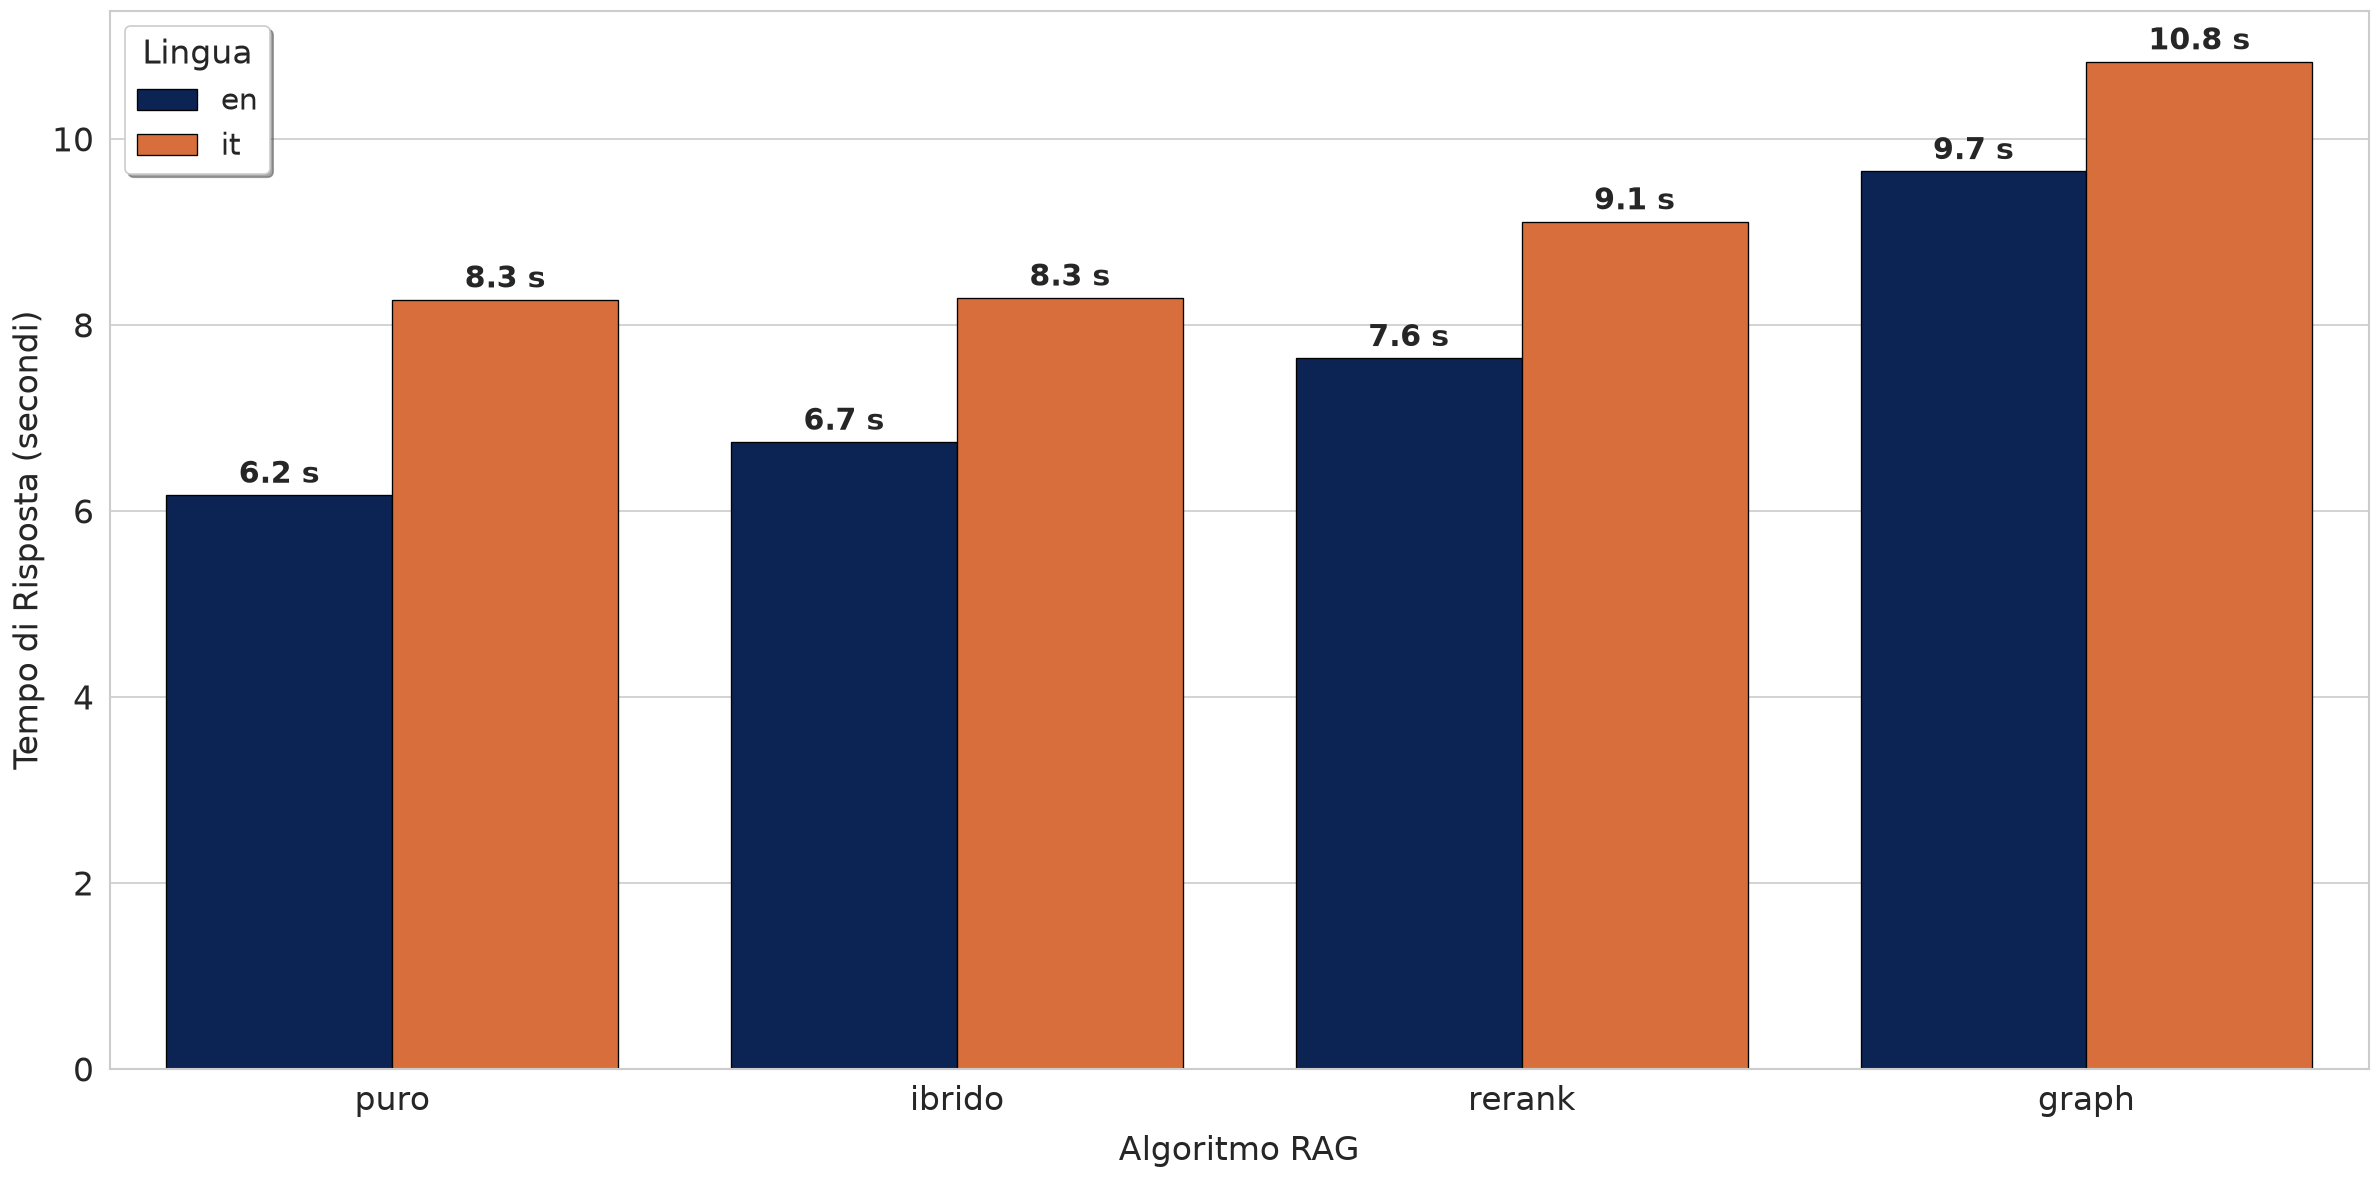

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
rag_order = ['puro', 'ibrido', 'rerank', 'graph']

data_subset = df_llm[df_llm['env'] == 'cloud']

colors_lang = {
    'en': '#002060',
    'it': '#f26522'
}

sns.barplot(
    data=data_subset,
    x='rag',
    order=rag_order,
    y='Response Time (s)',
    hue='lang',
    ax=ax,
    palette=colors_lang,
    edgecolor='black',
    linewidth=0.8
)

# ax.set_title(f'Tempo Medio Risposta (s)', fontsize=TITLE_FONTSIZE, fontweight='bold', pad=15)
ax.set_xlabel('Algoritmo RAG', fontsize=LABEL_FONTSIZE, labelpad=10)
ax.set_ylabel('Tempo (secondi)', fontsize=LABEL_FONTSIZE)

# Legenda ingrandita
ax.legend(
    title='Lingua',
    frameon=True,
    shadow=True,
    fontsize=LEGEND_FONTSIZE,
    title_fontsize=LEGEND_TITLE_FONTSIZE
)

ax.set_ylabel('Tempo di Risposta (secondi)', fontsize=LABEL_FONTSIZE)

ax.tick_params(axis='x', labelsize=LABEL_FONTSIZE)
ax.tick_params(axis='y', labelsize=LABEL_FONTSIZE)

# Aggiunta dei valori numerici sopra le barre
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f s', padding=3, fontsize=BAR_FONTSIZE, fontweight='bold')

plt.tight_layout()
plt.savefig("../thesis_report/images/pdf/tempo_medio_risposta_llm_cloud.pdf", bbox_inches='tight')
plt.savefig("../thesis_report/images/png/tempo_medio_risposta_llm_cloud.png", bbox_inches='tight')
plt.show()